In [104]:
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import run_omni_v2
importlib.reload(run_omni_v2)
from run_omni_v2 import omniprediction_multiq_online_v2, OmniResult

In [96]:
d = pickle.load(open('../data/hospitalizations/preprocess_data_medianinterp_weekly.pkl', 'rb'))
forecasts_dict = d['forecasts_dict']
f_list = d['forecaster_list']
alpha_list = d['alpha_list']
dates_list = d['dates_list']
Y = d['Y']
T = len(dates_list)

ens_model_names = ['COVIDhub-4_week_ensemble', 'COVIDhub-trained_ensemble', 'JHUAPL-SLPHospEns']
forecasts_wo_ens_dict = d['forecasts_dict'].copy()
for w in range(1,5):
    for ens_f in ens_model_names:
        forecasts_wo_ens_dict[w].pop(ens_f)

print(f_list)
print(alpha_list)
print(dates_list)
print(Y)

['CU-select', 'GT-DeepCOVID', 'COVIDhub-4_week_ensemble', 'COVIDhub-baseline', 'Karlen-pypm', 'JHU_IDD-CovidSP', 'MOBS-GLEAM_COVID', 'USC-SI_kJalpha', 'JHUAPL-Bucky', 'JHUAPL-SLPHospEns', 'JHUAPL-Gecko', 'COVIDhub-trained_ensemble']
[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]
Index(['2021-02-23', '2021-03-02', '2021-03-09', '2021-03-16', '2021-03-23',
       '2021-03-30', '2021-04-06', '2021-04-13', '2021-04-20', '2021-04-27',
       ...
       '2023-03-28', '2023-04-04', '2023-04-11', '2023-04-18', '2023-04-25',
       '2023-05-02', '2023-05-09', '2023-05-16', '2023-05-23', '2023-05-30'],
      dtype='str', length=119)
2021-02-23    39206.0
2021-03-02    34961.0
2021-03-09    33410.0
2021-03-16    33334.0
2021-03-23    35409.0
               ...   
2023-05-02     9721.0
2023-05-09     8832.0
2023-05-16     8328.0
2023-05-23     7579.0
2023-05-30     7310.0
Name: actual, Length: 119, dtype: float64


In [97]:
def decimal_to_str(eta):
    return str(np.round(eta, 4)).replace('.', ',')
    
def exp_name_string_v2(w, eta, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}{suffix}"

save_folder = 'hosp0315_weekly_v2'
SAVE_DIR = f'../results/{save_folder}'

# alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
alpha_list_here = alpha_list

In [105]:
####################################
no_ens = True
eta_list = np.round(np.power(10, np.arange(-1, 1.6, 0.25)), 4)
####################################

forecasts_dict_to_use = forecasts_wo_ens_dict if no_ens else forecasts_dict
for w in range(1,5):
    print(f"Running wk{w}...")
    for eta_multiplier in tqdm(eta_list, desc=f"Different eta_multiplier"):
        results = omniprediction_multiq_online_v2(Y=d['Y'][d['dates_list']], 
                                                forecasts_dict=forecasts_dict_to_use[w], 
                                                unit=500, 
                                                alpha_list=alpha_list_here, 
                                                eta_multiplier=eta_multiplier, 
                                                seed_list=[], 
                                                verbose=False
                                                )
        exp_name = exp_name_string_v2(w, eta_multiplier, suffix=f'_noens' if no_ens else '')
        # omni_result = OmniResult(results)
        pickle.dump(results, open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'wb'))
        # pickle.dump(omni_result, open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'wb'))
    break

Running wk1...


Different eta_multiplier:   0%|          | 0/11 [00:00<?, ?it/s]

time2: 0.006386518478393555, time3: 0.0003638267517089844
time2: 0.006333351135253906, time3: 0.00034546852111816406
time2: 0.006319761276245117, time3: 0.0002334117889404297
time2: 0.006358623504638672, time3: 0.0002779960632324219
time2: 0.006197690963745117, time3: 0.00025343894958496094
time2: 0.006317615509033203, time3: 0.0003573894500732422
time2: 0.006165266036987305, time3: 0.0002562999725341797
time2: 0.006214618682861328, time3: 0.00030040740966796875
time2: 0.006292819976806641, time3: 0.0002994537353515625
time2: 0.006337165832519531, time3: 0.0003705024719238281
time2: 0.006277799606323242, time3: 0.00025153160095214844
time2: 0.006289005279541016, time3: 0.0002410411834716797
time2: 0.00639653205871582, time3: 0.00023937225341796875
time2: 0.00644373893737793, time3: 0.00028705596923828125
time2: 0.006375312805175781, time3: 0.0002484321594238281
time2: 0.006525516510009766, time3: 0.0002810955047607422
time2: 0.006444454193115234, time3: 0.00022459030151367188
time2: 0.

Different eta_multiplier:   0%|          | 0/11 [00:00<?, ?it/s]

time2: 0.005837678909301758, time3: 0.0004837512969970703
time2: 0.005748748779296875, time3: 0.0002751350402832031
time2: 0.004939556121826172, time3: 0.0002505779266357422


AssertionError: j_opt: 317, j_opt_v3: 314

In [ ]:
# fig, ax = plt.subplots(2, 6, figsize=(18, 8))
# ax = ax.flatten()

w=1
for i, eta_mult in enumerate(eta_list):
    exp_name = exp_name_string_v2(w, eta_mult)
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))
    w_history = results['w_history']
    #print(w_history.sum(axis=2)[-1,:,0])
    print(np.max(results['omni_error_history'].cumsum(axis=0), axis=(1,2)))
    # ax[i].plot(w_history.sum(axis=1))

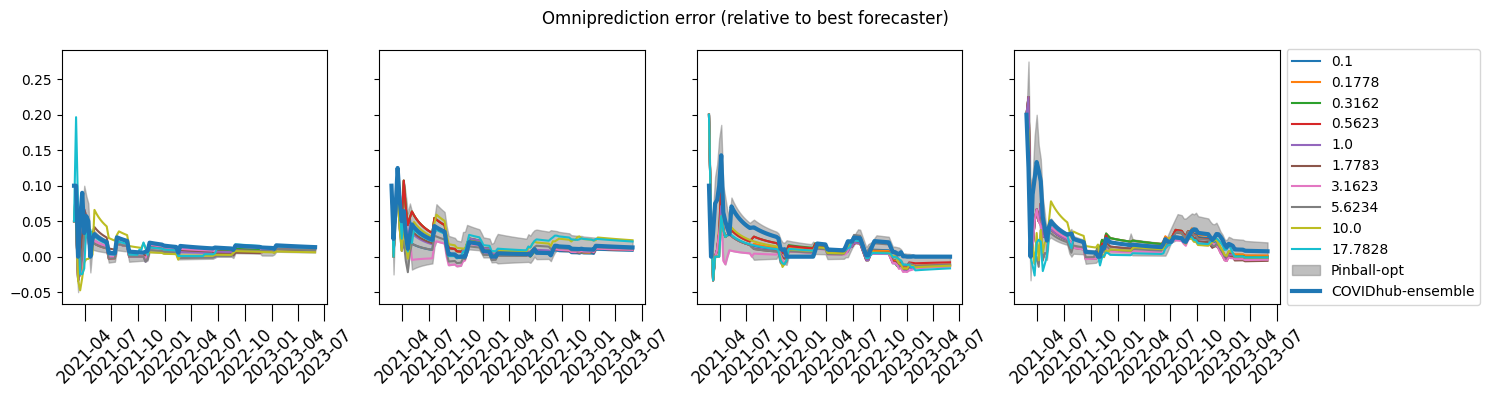

In [69]:
dates_list = pd.to_datetime(d['dates_list'])
T = len(dates_list)

def exp_name_string_ql_pb(w, eta, round_Y_F, suffix=''):
    return f"wk{w}_eta{decimal_to_str(eta)}{'_orig' if not round_Y_F else ''}{suffix}"


fig, ax = plt.subplots(1, 4, figsize=(15, 4), sharey='row')
for w in range(1,5):
    pinball_omni_trace_min_max = np.array([[np.inf]*T, [-np.inf]*T])
    for eta_mult in eta_list[:-1]:
        exp_name = exp_name_string_v2(w, eta_mult)
        results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name}.pkl", 'rb'))

        bfst = results['best_forecaster_score_trace']
        omni_rel_trace = (results['omni_score_trace'] - bfst)
        ax[w-1].plot(dates_list, omni_rel_trace, label=eta_mult)
        
        ens_omni_rel_trace = (results['forecasters_score_trace'][:,2] - bfst)
        
    for eta_mult in np.round(np.power(10, np.arange(-1, 3.6, 0.25)), 4):    
        results = pickle.load(open(f"../results/hosp0315_weekly_ql_pb/results_{exp_name_string_ql_pb(w, eta_mult, True)}.pkl", 'rb'))
        pinball_omni_trace_min_max[0] = np.minimum(pinball_omni_trace_min_max[0], results['pinball_omni_score_trace']-bfst)
        pinball_omni_trace_min_max[1] = np.maximum(pinball_omni_trace_min_max[1], results['pinball_omni_score_trace']-bfst)

    ax[w-1].fill_between(dates_list, pinball_omni_trace_min_max[0], pinball_omni_trace_min_max[1], color='gray', alpha=0.5, label='Pinball-opt')

    
    ax[w-1].plot(dates_list, ens_omni_rel_trace, linewidth=3, label='COVIDhub-ensemble')
    # ax[w-1].set_ylim(-0.05, 0.2)
    ax[w-1].tick_params(axis='x', labelrotation=45, labelsize=12, size=12)
    if w == 4:
        ax[w-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle('Omniprediction error (relative to best forecaster)')
fig.tight_layout()
plt.show()

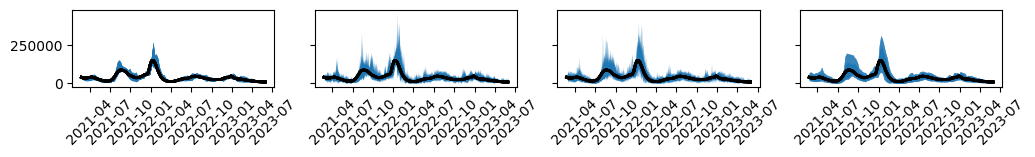

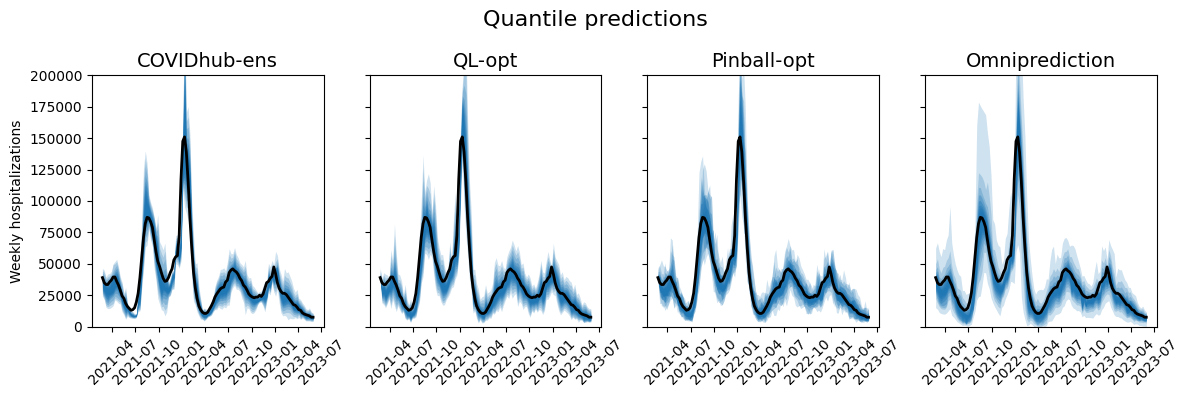

In [70]:
n_seed = 10

q_pred_omni = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_pb = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ql = np.zeros((len(d['dates_list']), len(d['alpha_list'])))
q_pred_ens = np.zeros((len(d['dates_list']), len(d['alpha_list'])))

fig, ax = plt.subplots(1, 4, figsize=(12, 1), sharey=True)
for seed in range(1, n_seed+1):
    omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name_string_v2(w=1, eta=0.5,  seed=seed)}.pkl", 'rb'))
    if seed == 10:
        fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
        omni_result.quantile_plot(ax=ax[3], q_preds=q_pred_omni/n_seed)
        omni_result.quantile_plot(ax=ax[2], q_preds=q_pred_pb/n_seed)
        omni_result.quantile_plot(ax=ax[1], q_preds=q_pred_ql/n_seed)
        omni_result.quantile_plot(ax=ax[0], q_preds=q_pred_ens/n_seed)
    else:
        ax[3], q_pred_omni = omni_result.quantile_plot(f_name='omni', ax=ax[3], q_preds_to_add=q_pred_omni)
        ax[2], q_pred_pb = omni_result.quantile_plot(f_name='pinball', ax=ax[2], q_preds_to_add=q_pred_pb)
        ax[1], q_pred_ql = omni_result.quantile_plot(f_name='ql', ax=ax[1], q_preds_to_add=q_pred_ql)
        ax[0], q_pred_ens = omni_result.quantile_plot(f_name='ens', ax=ax[0], q_preds_to_add=q_pred_ens)

ax[3].set_title('Omniprediction', fontsize=14)
ax[2].set_title('Pinball-opt', fontsize=14)
ax[1].set_title('QL-opt', fontsize=14)
ax[0].set_title('COVIDhub-ens', fontsize=14)

ax[0].set_ylabel('Weekly hospitalizations')


ax[0].set_ylim(0, 200000)

fig.suptitle('Quantile predictions', fontsize=16)
fig.tight_layout()
plt.show()

0.057142857142857155
0.06974789915966385
0.06722689075630252
0.003187928467319607
0.004316787865216214
0.004006635473263641


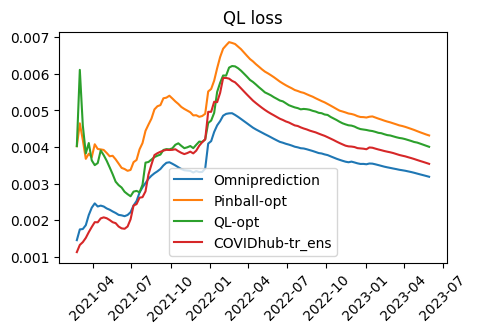

In [71]:
from metrics import ql_loss
w=1

exp_name = exp_name_string_v2(w, 0.5, seed=1)

omni_result = pickle.load(open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", 'rb'))
results = omni_result.results

T = results['T']
Y = results['Y']
m = results['m']

print(results['omni_score_trace'][T-1])
print(omni_result.pinball_omni_score_trace[T-1])
print(omni_result.ql_omni_score_trace[T-1])

print(ql_loss(results['phat_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).mean()/m)
print(ql_loss(results['ql_preds_history'], Y, results['alpha_list']).mean()/m)

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['phat_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Omniprediction')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['pinball_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='Pinball-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['ql_preds_history'], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='QL-opt')
plt.plot(pd.to_datetime(d['dates_list']), ql_loss(results['forecasters_preds_history'][:,:,-1], Y, results['alpha_list']).cumsum() / m / np.arange(1, T+1), label='COVIDhub-tr_ens')
plt.xticks(rotation=45)
plt.legend()
plt.title('QL loss')
plt.show()

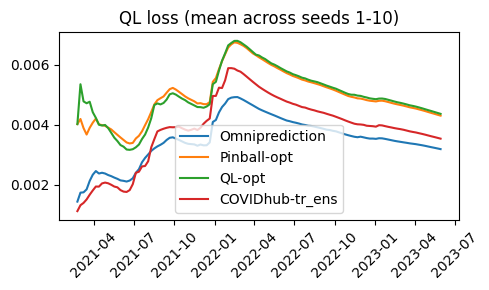

In [72]:
from metrics import ql_loss

w = 1
seed_list = list(range(1, 11))

omni_curves = []
pinball_curves = []
qlopt_curves = []
ens_curves = []

for seed in seed_list:
    exp_name = exp_name_string_v2(w, 0.5, seed=seed)
    with open(f"{SAVE_DIR}/postprocessed_{exp_name}.pkl", "rb") as f:
        omni_result = pickle.load(f)
    results = omni_result.results

    T = results["T"]
    Y = results["Y"]
    m = results["m"]
    alpha_list = results["alpha_list"]

    denom = m * np.arange(1, T + 1)
    omni_curves.append(ql_loss(results["phat_history"], Y, alpha_list).cumsum() / denom)
    pinball_curves.append(ql_loss(results["pinball_preds_history"], Y, alpha_list).cumsum() / denom)
    qlopt_curves.append(ql_loss(results["ql_preds_history"], Y, alpha_list).cumsum() / denom)
    ens_curves.append(ql_loss(results["forecasters_preds_history"][:, :, -1], Y, alpha_list).cumsum() / denom)

omni_mean = np.mean(np.vstack(omni_curves), axis=0)
pinball_mean = np.mean(np.vstack(pinball_curves), axis=0)
qlopt_mean = np.mean(np.vstack(qlopt_curves), axis=0)
ens_mean = np.mean(np.vstack(ens_curves), axis=0)

dates = pd.to_datetime(d["dates_list"])

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(dates, omni_mean, label="Omniprediction")
ax.plot(dates, pinball_mean, label="Pinball-opt")
ax.plot(dates, qlopt_mean, label="QL-opt")
ax.plot(dates, ens_mean, label="COVIDhub-tr_ens")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.set_title("QL loss (mean across seeds 1-10)")
plt.tight_layout()
plt.show()

100%|██████████| 10/10 [00:01<00:00,  7.18it/s]


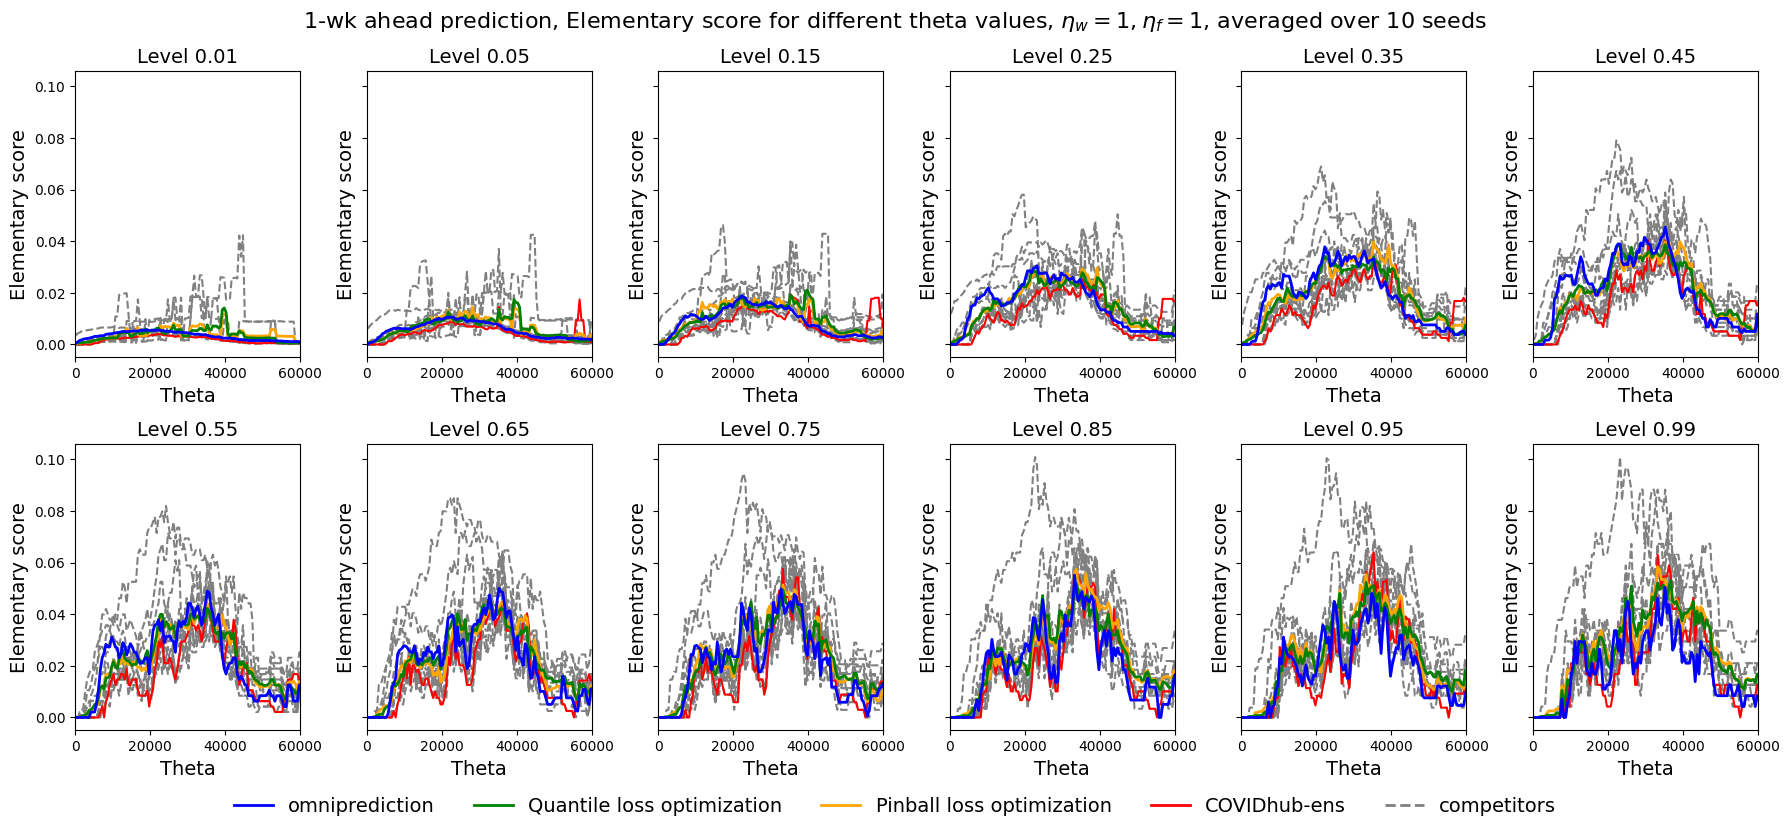

In [74]:
import importlib
import metrics
importlib.reload(metrics)
from metrics import elementary_scores_grid_T_N, elementary_scores_grid_T_N_F
from tqdm import tqdm

w=1
F=12
eta_multiplier = 0.5    

results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, eta_multiplier, 1)}.pkl", 'rb'))
thetas = results['thetas']

omni_murphy = np.zeros((len(alpha_list), len(thetas)))
ql_murphy = np.zeros((len(alpha_list), len(thetas)))
pb_murphy = np.zeros((len(alpha_list), len(thetas)))
f_murphy = np.zeros((len(alpha_list), len(thetas), F))

for seed in tqdm(range(1, 11)):
    results = pickle.load(open(f"{SAVE_DIR}/results_{exp_name_string_v2(w, eta_multiplier, seed)}.pkl", 'rb'))
    omni_result = OmniResult(results)

    thetas = results['thetas']
    unit = results['unit'] 
    F = results['F']
    forecaster_names = results['forecaster_names']

    omni_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['phat_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    ql_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['ql_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    pb_murphy += elementary_scores_grid_T_N(p_grid_T_N=results['pinball_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)
    f_murphy += elementary_scores_grid_T_N_F(p_grid_T_N_F=results['forecasters_preds_history'], y=results['Y'].values, thetas=results['thetas'], alpha_list=results['alpha_list']).mean(axis=0)

omni_murphy /= 10
ql_murphy /= 10
pb_murphy /= 10
f_murphy /= 10

fig, ax = plt.subplots(2, 6, figsize=(18, 8), sharey=True)
ax = ax.flatten()

for ia, alpha in enumerate(alpha_list[::2]):
    df = omni_result.single_q_pred_df(ia)
    
    for f in range(F):
        if f < F-1:
            ax[ia].plot(thetas*unit, f_murphy[ia,:,f], linestyle='--', color='gray')
        else:
            ax[ia].plot(thetas*unit, f_murphy[ia,:,f], linestyle='-', color='red')
    ax[ia].plot(thetas*unit, pb_murphy[ia,:], color='orange', linewidth=2, label='Pinball loss optimization')
    ax[ia].plot(thetas*unit, ql_murphy[ia,:], color='green', linewidth=2, label='Quantile loss optimization')
    ax[ia].plot(thetas*unit, omni_murphy[ia,:], color='blue', linewidth=2, label='omniprediction')    

    # if ia == 4:
    # Add a custom legend to the bottom of the entire figure
    ax[ia].set_xlabel('Theta', fontsize=14)
    ax[ia].set_ylabel('Elementary score', fontsize=14)
    ax[ia].set_title(f'Level {alpha}', fontsize=14)
    ax[ia].set_xlim(0, 60000)

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='blue', linewidth=2, label='omniprediction'),
    Line2D([0], [0], color='green', linewidth=2, label='Quantile loss optimization'),
    Line2D([0], [0], color='orange', linewidth=2, label='Pinball loss optimization'),
    Line2D([0], [0], color='red', linewidth=2, label='COVIDhub-ens'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='competitors'),
]
fig.legend(
    handles=custom_lines, 
    loc='lower center', 
    ncol=5, 
    bbox_to_anchor=(0.5, -0.05), 
    fontsize=14, 
    frameon=False
)

fig.suptitle(rf'{w}-wk ahead prediction, Elementary score for different theta values, $\eta_w=1, \eta_f=1$, averaged over 10 seeds', fontsize=16)
fig.tight_layout()
plt.show()

